In [67]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# --- RDKit Chemistry ---
import rdkit.Chem as Chem
from rdkit import DataStructs, RDLogger
from rdkit.Chem import AllChem, Crippen, Descriptors, rdMolDescriptors
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.Scaffolds import MurckoScaffold

RDLogger.DisableLog("rdApp.*")

# --- Pytorch ---
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.data import Dataset
from torch_geometric.nn import GINConv, GCNConv, GATConv, global_add_pool, global_max_pool, global_mean_pool


# --- Visualization ---
import matplotlib.pyplot as plt
import umap.umap_ as umap

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

In [2]:
raw = pd.read_csv(r"data/CHEMBL1792.csv", sep=";", low_memory=False)

In [3]:
raw['Standard Type'].value_counts()

Standard Type
IC50                     847
Ki                       499
EC50                     124
kon                      110
k_off                    110
Imax                      58
Kd                        34
Inhibition                30
Activity                  11
pKD                        5
pKd                        5
Flu intensity              1
Mean fold stimulation      1
RLU                        1
Name: count, dtype: int64

In [4]:
df = raw[raw['Standard Type']=='IC50'].copy()

In [5]:
print(f"The shape of the dataset is {df.shape}\n")
print(df.info())

The shape of the dataset is (847, 48)

<class 'pandas.core.frame.DataFrame'>
Index: 847 entries, 1 to 1801
Data columns (total 48 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Molecule ChEMBL ID          847 non-null    object 
 1   Molecule Name               13 non-null     object 
 2   Molecule Max Phase          11 non-null     float64
 3   Molecular Weight            847 non-null    float64
 4   #RO5 Violations             405 non-null    float64
 5   AlogP                       405 non-null    float64
 6   Compound Key                847 non-null    object 
 7   Smiles                      843 non-null    object 
 8   Standard Type               847 non-null    object 
 9   Standard Relation           843 non-null    object 
 10  Standard Value              843 non-null    float64
 11  Standard Units              846 non-null    object 
 12  pChEMBL Value               642 non-null    float64
 13  

In [6]:
print(df['Standard Units'].value_counts())

df.dropna(subset=['Smiles', 'Standard Units', 'Standard Relation', 'Standard Value'], inplace=True)
print(df.shape)
print(df.info())

Standard Units
nM    846
Name: count, dtype: int64
(839, 48)
<class 'pandas.core.frame.DataFrame'>
Index: 839 entries, 1 to 1801
Data columns (total 48 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Molecule ChEMBL ID          839 non-null    object 
 1   Molecule Name               9 non-null      object 
 2   Molecule Max Phase          9 non-null      float64
 3   Molecular Weight            839 non-null    float64
 4   #RO5 Violations             404 non-null    float64
 5   AlogP                       404 non-null    float64
 6   Compound Key                839 non-null    object 
 7   Smiles                      839 non-null    object 
 8   Standard Type               839 non-null    object 
 9   Standard Relation           839 non-null    object 
 10  Standard Value              839 non-null    float64
 11  Standard Units              839 non-null    object 
 12  pChEMBL Value               638 non

In [78]:
df = df[df['Standard Relation']=="'='"].copy()
df.head()

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
3,CHEMBL442605,NaN,NaN,603.64,0.0,2.41,21,CC(=O)N[C@@H]1Cc2c([nH]c3ccccc23)CN([C@@H](CCC...,IC50,'=',...,CHEMBL1139341,1,Scientific Literature,J Med Chem,2009,NaN,NaN,NaN,NaN,0.560
4,CHEMBL448026,NaN,NaN,679.74,1.0,3.98,10b,NCCCC[C@@H](C(=O)NCc1ccccc1)N1Cc2[nH]c3ccccc3c...,IC50,'=',...,CHEMBL1139341,1,Scientific Literature,J Med Chem,2009,NaN,NaN,NaN,NaN,3.400
5,CHEMBL3665793,NaN,NaN,556.59,2.0,5.80,BDBM123209,CC(C)(C)n1cc(CN2CCCC3(CC2)CN(c2ccc(C(=O)O)cc2)...,IC50,'=',...,CHEMBL3639241,37,BindingDB Patent Bioactivity Data,NaN,2014,NaN,NaN,NaN,NaN,206.700
6,CHEMBL3665796,NaN,NaN,532.64,2.0,5.39,BDBM123212,COc1ccc(-c2nn(C(C)(C)C)cc2CN2CCCC3(CC2)CN(c2cc...,IC50,'=',...,CHEMBL3639241,37,BindingDB Patent Bioactivity Data,NaN,2014,NaN,NaN,NaN,NaN,26.770
7,CHEMBL3665813,NaN,NaN,548.61,2.0,5.98,BDBM123229,CCOc1cc(CN2CCC3(CC2)CN(c2cccc(C(=O)O)c2)C(=O)O...,IC50,'=',...,CHEMBL3639241,37,BindingDB Patent Bioactivity Data,NaN,2014,NaN,NaN,NaN,NaN,9.153


In [79]:
select_col = ['Smiles', 'Standard Value']
df = df[select_col]
df.head()

,Smiles,Standard Value
3,CC(=O)N[C@@H]1Cc2c([nH]c3ccccc23)CN([C@@H](CCC...,0.560
4,NCCCC[C@@H](C(=O)NCc1ccccc1)N1Cc2[nH]c3ccccc3c...,3.400
5,CC(C)(C)n1cc(CN2CCCC3(CC2)CN(c2ccc(C(=O)O)cc2)...,206.700
6,COc1ccc(-c2nn(C(C)(C)C)cc2CN2CCCC3(CC2)CN(c2cc...,26.770
7,CCOc1cc(CN2CCC3(CC2)CN(c2cccc(C(=O)O)c2)C(=O)O...,9.153


In [80]:
def standardize(smiles):

    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        return None

    clean_mol = rdMolStandardize.Cleanup(mol)

    parent_clean_mol = rdMolStandardize.FragmentParent(clean_mol)

    uncharger = rdMolStandardize.Uncharger() 
    uncharged_parent_clean_mol = uncharger.uncharge(parent_clean_mol)

    te = rdMolStandardize.TautomerEnumerator() 
    taut_uncharged_parent_clean_mol = te.Canonicalize(uncharged_parent_clean_mol)

    return Chem.MolToSmiles(taut_uncharged_parent_clean_mol)

df["Standardized Smiles"] = df["Smiles"].apply(standardize)

[22:45:43] Initializing MetalDisconnector
[22:45:43] Running MetalDisconnector
[22:45:43] Initializing Normalizer
[22:45:43] Running Normalizer
[22:45:43] Initializing MetalDisconnector
[22:45:43] Running MetalDisconnector
[22:45:43] Initializing Normalizer
[22:45:43] Running Normalizer
[22:45:43] Running LargestFragmentChooser
[22:45:43] Fragment: CC(=O)N[C@@H]1Cc2c([nH]c3ccccc23)CN([C@@H](CCCCN)C(=O)NCCc2ccccc2)C1=O
[22:45:43] New largest fragment: CC(=O)N[C@@H]1Cc2c([nH]c3ccccc23)CN([C@@H](CCCCN)C(=O)NCCc2ccccc2)C1=O (71)
[22:45:43] Fragment: O=C(O)C(F)(F)F
[22:45:43] Running Uncharger
[22:45:43] Initializing MetalDisconnector
[22:45:43] Running MetalDisconnector
[22:45:43] Initializing Normalizer
[22:45:43] Running Normalizer
[22:45:43] Initializing MetalDisconnector
[22:45:43] Running MetalDisconnector
[22:45:43] Initializing Normalizer
[22:45:43] Running Normalizer
[22:45:43] Running LargestFragmentChooser
[22:45:43] Fragment: NCCCC[C@@H](C(=O)NCc1ccccc1)N1Cc2[nH]c3ccccc3c2C[C@@H

# From Here

In [7]:
df = pd.read_csv("data/CHEMBL1792_cleaned.csv")

select_col = ['Smiles', 'Standard Value', 'Standardized Smiles']
df = df[select_col]

def fp_scaffold(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return {
            "inchi_key": None,
            "scaffold": None,
            "MolWt": None,
            "NumHDonors": None,
            "NumHAcceptors": None,
            "TPSA": None,
            "NumRotatableBonds": None,
            "NumAromaticRings": None,
            "logP": None,
            "fp": None,
        }

    # Fingerprint
    fp_rdkit = AllChem.GetMorganFingerprintAsBitVect(
        mol, radius=2, nBits=2048
    )
    fp_numpy = np.zeros((2048,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp_rdkit, fp_numpy)

    # Scaffold
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    scaffold_smiles = Chem.MolToSmiles(scaffold)

    return {
            "inchi_key": Chem.MolToInchiKey(mol),
            "scaffold": scaffold_smiles,
            "MolWt": Descriptors.ExactMolWt(mol),
            "NumHDonors": rdMolDescriptors.CalcNumHBD(mol),
            "NumHAcceptors": rdMolDescriptors.CalcNumHBA(mol),
            "TPSA": rdMolDescriptors.CalcTPSA(mol),
            "NumRotatableBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
            "NumAromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
            "logP": Crippen.MolLogP(mol),
            "fp": fp_numpy,
        }
props = df["Standardized Smiles"].apply(fp_scaffold).apply(pd.Series)

df = pd.concat([df, props], axis=1)

df.rename(columns={'Standard Value': 'IC50'}, inplace=True)
df['pIC50'] = 9 - np.log10(df['IC50'].astype(float))

In [8]:
def remove_dupli_inchi(df_bak, dupli_inchis):
    
    dupli_inchi_bak = df_bak["inchi_key"].value_counts() != 1

    dupli_inchis = (df_bak["inchi_key"].value_counts())[dupli_inchi_bak].index

    for inchi in dupli_inchis:
        median_value = df_bak[df_bak["inchi_key"] == inchi]["IC50"].median()
        index = df_bak[df_bak["inchi_key"] == inchi].index[0]
        single_input = df_bak[df_bak["inchi_key"] == inchi].loc[[index]]
        single_input["inchi_key"] = median_value
        
        df_bak.drop(index=df_bak[df_bak["inchi_key"] == inchi].index, inplace=True)
        df_bak = pd.concat([df_bak, single_input], ignore_index=True)
    return df_bak.reset_index(drop=True)

dupli_inchi = df["inchi_key"].value_counts() != 1
dupli_inchis = (df["inchi_key"].value_counts())[dupli_inchi].index

df = remove_dupli_inchi(df, dupli_inchis)
len(df)

495

In [9]:
df.describe()

,IC50,MolWt,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,NumAromaticRings,logP,pIC50
count,495.000000,495.000000,495.000000,495.000000,495.000000,495.000000,495.000000,495.000000,495.000000
mean,660.470402,782.727106,6.092929,9.076768,199.973455,11.812121,3.856566,3.442372,7.537142
std,2876.904725,381.468131,6.806124,5.865752,168.960046,7.771995,1.279562,3.161214,1.184059
min,0.129000,381.205242,0.000000,3.000000,41.930000,4.000000,2.000000,-16.464800,4.480041
25%,2.900000,519.226943,1.000000,5.000000,84.240000,6.000000,3.000000,1.844900,6.657577
50%,28.000000,565.305290,2.000000,6.000000,97.130000,10.000000,4.000000,4.546600,7.552842
75%,220.000000,1105.937770,12.000000,13.000000,336.390000,16.500000,5.000000,5.646200,8.537602
max,33110.000000,3146.463699,44.000000,46.000000,1321.810000,76.000000,9.000000,7.677220,9.889410


In [10]:
scaffold_counts = (df['scaffold'].value_counts().reset_index())

scaffold_counts.columns = ['scaffold', 'count']

print(f'Length of the total unique scaffolds is {len(scaffold_counts)}')

target = len(df) * 0.7

cum_sum = scaffold_counts['count'].cumsum()
threshold = cum_sum.ge(target).idxmax()   

print(f"Threshold index: {threshold}")
print(f"Cumulative count: {cum_sum.iloc[threshold]}")

train_scaffold = scaffold_counts.iloc[:threshold+1]['scaffold'].tolist()
test_scaffold = scaffold_counts.iloc[threshold+1:]['scaffold'].tolist()

Length of the total unique scaffolds is 248
Threshold index: 99
Cumulative count: 347


In [11]:
print(len(df[df['scaffold'].isin(train_scaffold)]), len(df[df['scaffold'].isin(test_scaffold)]))

347 148


In [12]:
train_dataset = df[df['scaffold'].isin(train_scaffold)].reset_index(drop=True)

test_dataset = df[df['scaffold'].isin(test_scaffold)].reset_index(drop=True)

In [13]:
# Convert the 'fp' column containing feature vectors into a 2D matrix
X_fp = np.vstack(train_dataset['fp'].values)

# Create UMAP instance
umap_model = umap.UMAP(n_components=2, random_state=42)

# Fit and transform
X_fp_umap = umap_model.fit_transform(X_fp)

print(X_fp_umap.shape)

train_dataset['UMAP_1'] = X_fp_umap[:, 0]
train_dataset['UMAP_2'] = X_fp_umap[:, 1]

c:\Users\yashd\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(347, 2)


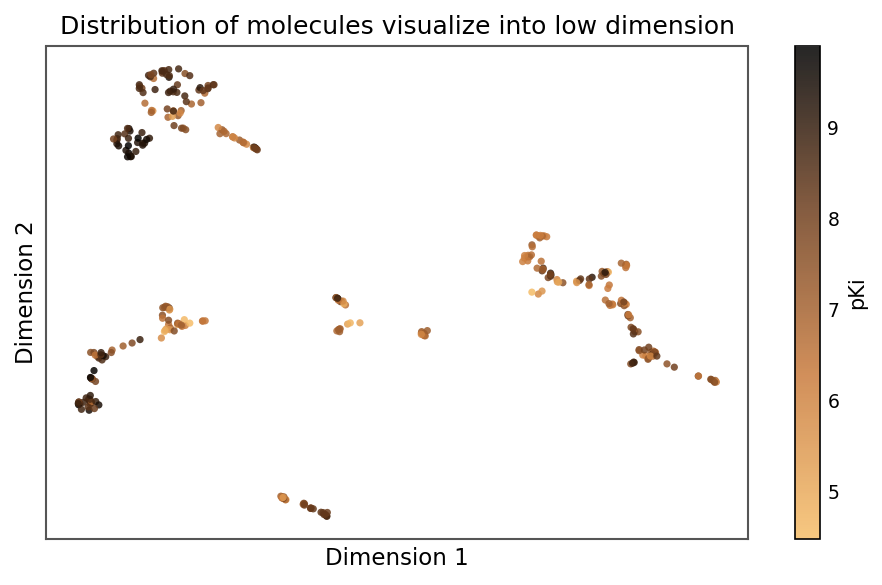

In [14]:
paper_cmap = LinearSegmentedColormap.from_list("paper_orange_black",
                                                            [
                                                                "#F6BE6A",   # light orange
                                                                "#C97B3D",   # brown-orange
                                                                "#70401F",   # dark brown
                                                                "#000000"    # black
                                                            ])

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
scatter = ax.scatter( train_dataset['UMAP_1'], train_dataset['UMAP_2'], c=train_dataset['pIC50'], cmap=paper_cmap, s=12, alpha=0.85, edgecolors='none')

ax.set_xlabel("Dimension 1",fontsize=11)
ax.set_ylabel("Dimension 2", fontsize=11)
ax.tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

# Thin gray border
for spine in ax.spines.values():
    spine.set_color("#555555")
    spine.set_linewidth(1.0)
    
cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.06)
cbar.set_label("pKi", fontsize=10)
cbar.ax.tick_params(labelsize=9, length=0)
cbar.outline.set_linewidth(0.8)

plt.title("Distribution of molecules visualize into low dimension")
plt.tight_layout()
plt.savefig("plots/UMAP_Bioactivity_Projection.png", dpi=300, bbox_inches="tight")
plt.show()

In [179]:
def get_atom_bonds(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None
    mol = Chem.AddHs(mol)
    atoms = []
    for atm in mol.GetAtoms():
        atoms.append(np.array([ atm.GetAtomicNum() * 0.01,
                                atm.GetMass() * 0.01,
                                atm.GetDegree() * 0.01,
                                atm.GetFormalCharge(),
                                int(atm.GetIsAromatic()),
                                int(atm.GetNumRadicalElectrons())], dtype=np.float32))
    
    bonds = []  
    for bond in mol.GetBonds():
        bonds.append([bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()])
        bonds.append([bond.GetEndAtomIdx(), bond.GetBeginAtomIdx()])
        
    return np.array(atoms), np.array(bonds).transpose()

train_dataset[["atoms", "bonds"]] = train_dataset["Smiles"].apply(lambda x: pd.Series(get_atom_bonds(x)))
test_dataset[["atoms", "bonds"]] = train_dataset["Smiles"].apply(lambda x: pd.Series(get_atom_bonds(x)))

In [180]:
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader

class GraphDataset(Dataset):
    def __init__(self, X, y, z):
        super().__init__()
        self.graphs = X.values
        self.targets = y.values.astype(float)
        self.fps = z

    def len(self):
        return len(self.graphs)

    def get(self, idx):
        x = torch.tensor(self.graphs[idx][0], dtype=torch.float)
        edge_index = torch.tensor(self.graphs[idx][1], dtype=torch.long)
        
        fps = torch.tensor(self.fps[idx], dtype=torch.float)

        y = torch.tensor([self.targets[idx]], dtype=torch.float)

        return Data(
            x=x,
            fps = fps,
            edge_index=edge_index,
            y=y
        )
        
train_dataset_pyg = GraphDataset(train_dataset[['atoms', 'bonds']], train_dataset['pIC50'], train_dataset['fp'])
test_dataset_pyg = GraphDataset(test_dataset[['atoms', 'bonds']], test_dataset['pIC50'], test_dataset['fp'])

train_loader = DataLoader(train_dataset_pyg, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset_pyg, batch_size=128)

In [181]:
for x, fp, edge, y in train_dataset_pyg:
    print(x)
    print(fp.shape)
    print(edge)
    print(y)
    break

('x', tensor([[0.0600, 0.1201, 0.0400, 0.0000, 0.0000, 0.0000],
        [0.0600, 0.1201, 0.0400, 0.0000, 0.0000, 0.0000],
        [0.0600, 0.1201, 0.0400, 0.0000, 0.0000, 0.0000],
        [0.0600, 0.1201, 0.0400, 0.0000, 0.0000, 0.0000],
        [0.0700, 0.1401, 0.0300, 0.0000, 1.0000, 0.0000],
        [0.0600, 0.1201, 0.0300, 0.0000, 1.0000, 0.0000],
        [0.0600, 0.1201, 0.0300, 0.0000, 1.0000, 0.0000],
        [0.0600, 0.1201, 0.0400, 0.0000, 0.0000, 0.0000],
        [0.0700, 0.1401, 0.0300, 0.0000, 0.0000, 0.0000],
        [0.0600, 0.1201, 0.0400, 0.0000, 0.0000, 0.0000],
        [0.0600, 0.1201, 0.0400, 0.0000, 0.0000, 0.0000],
        [0.0600, 0.1201, 0.0400, 0.0000, 0.0000, 0.0000],
        [0.0600, 0.1201, 0.0400, 0.0000, 0.0000, 0.0000],
        [0.0600, 0.1201, 0.0400, 0.0000, 0.0000, 0.0000],
        [0.0600, 0.1201, 0.0400, 0.0000, 0.0000, 0.0000],
        [0.0600, 0.1201, 0.0400, 0.0000, 0.0000, 0.0000],
        [0.0700, 0.1401, 0.0300, 0.0000, 0.0000, 0.0000],
        

AttributeError: 'tuple' object has no attribute 'shape'

In [182]:
class GIN(nn.Module):
    def __init__(self, num_node_features):
        super().__init__()
        
        self.conv1 = GINConv(nn.Sequential(
            nn.Linear(num_node_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 64),
        ))
        
        self.conv2 = GINConv(nn.Sequential(
            nn.Linear(64, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 64),      
        ))
        
        self.conv3 = GINConv(nn.Sequential(
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 128),      
        ))
        
        self.conv4 = GINConv(nn.Sequential(
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 128),      
        ))
        
        self.mlp = nn.Sequential(
            nn.Linear(128+2048, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 1)
        )
        
    def forward(self, atom_num, edges_index, fp, batch):
        z = self.conv1(atom_num, edges_index)
        z = F.relu(z)
        z = self.conv2(z, edges_index)
        z = F.relu(z)
        z = self.conv3(z, edges_index)
        z = F.relu(z)
        z = self.conv4(z, edges_index)
        z = F.relu(z)

        z = global_add_pool(z, batch)

        # Recover the batch dimension
        fp = fp.view(z.size(0), 2048)

        z = torch.cat([z, fp], dim=1)

        z = self.mlp(z)

        return z

In [183]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GIN(6).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()

In [184]:
num_epochs = 30

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for batch in train_loader:
        batch = batch.to(device)

        optimizer.zero_grad()

        pred = model(batch.x, batch.edge_index, batch.fps, batch.batch)

        loss = loss_fn(pred.squeeze(), batch.y.squeeze())

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    print(f"Epoch {epoch+1:3d} | Loss: {train_loss:.4f}")

Epoch   1 | Loss: 40.0126
Epoch   2 | Loss: 14.1667
Epoch   3 | Loss: 7.8693
Epoch   4 | Loss: 4.1617
Epoch   5 | Loss: 3.6332
Epoch   6 | Loss: 2.6616
Epoch   7 | Loss: 3.1782
Epoch   8 | Loss: 2.6774
Epoch   9 | Loss: 2.0126
Epoch  10 | Loss: 1.8965
Epoch  11 | Loss: 1.6945
Epoch  12 | Loss: 1.5638
Epoch  13 | Loss: 1.7293
Epoch  14 | Loss: 1.5669
Epoch  15 | Loss: 1.4113
Epoch  16 | Loss: 1.4197
Epoch  17 | Loss: 1.9097
Epoch  18 | Loss: 1.5203
Epoch  19 | Loss: 1.5829
Epoch  20 | Loss: 1.3982
Epoch  21 | Loss: 1.3341
Epoch  22 | Loss: 1.2971
Epoch  23 | Loss: 1.2685
Epoch  24 | Loss: 1.2323
Epoch  25 | Loss: 1.1667
Epoch  26 | Loss: 1.0604
Epoch  27 | Loss: 1.0636
Epoch  28 | Loss: 1.0406
Epoch  29 | Loss: 0.9086
Epoch  30 | Loss: 0.9113


In [186]:
model.eval()

test_loss = 0
all_preds = []
all_targets = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)

        pred = model(batch.x, batch.edge_index, batch.fps, batch.batch)

        loss = loss_fn(pred.squeeze(), batch.y.squeeze())
        test_loss += loss.item()

        all_preds.extend(pred.squeeze().cpu().numpy())
        all_targets.extend(batch.y.squeeze().cpu().numpy())

test_loss /= len(test_loader)

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

r2 = r2_score(all_targets, all_preds)
rmse = np.sqrt(mean_squared_error(all_targets, all_preds))

print(f"Test Loss: {test_loss:.4f}")
print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.4f}")

Test Loss: 2.1716
R² Score : -0.6657
RMSE     : 1.4558


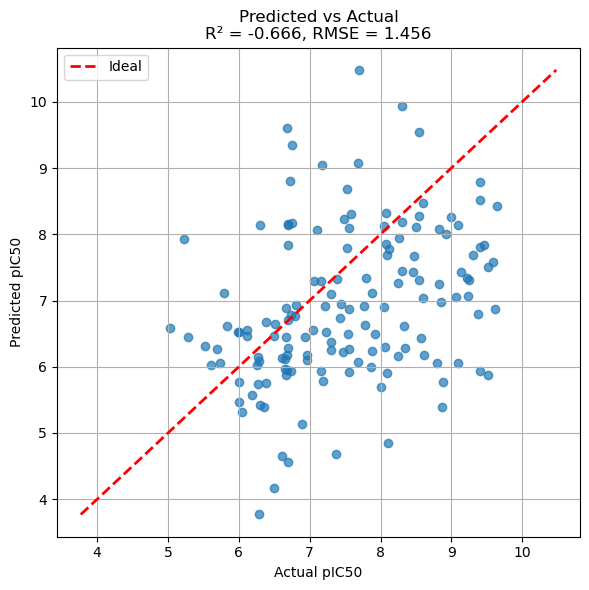

In [187]:
plt.figure(figsize=(6, 6))

plt.scatter(all_targets, all_preds, alpha=0.7)

# Ideal prediction line (y = x)
min_val = min(all_targets.min(), all_preds.min())
max_val = max(all_targets.max(), all_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal')

plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")
plt.title(f"Predicted vs Actual\nR² = {r2:.3f}, RMSE = {rmse:.3f}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()